# E05 - Source-Conditioned CPU Speed: five levers to cut d(A,B|S) latency >= 50%

**Author**: Konrad Jelen (kj)<br>
**Batch**: E05 - source-conditioned CPU speed (pre-registered in `docs/experiments/wmd-docdistance-experiments.md`)

The source-conditioned grounding axis `D_grd` is fast on GPU (fp16, ~1.7 s/pair) but the project ships as portable
OpenVINO INT8 on any CPU, where the shipped chain is ~67 s/pair and **~99% the reranker grid** (the 109 s figure
includes a diagnostic R1 NLI sweep the shipped relevance-gate + R2 chain never runs). E03/E04 proved the reranker
*model* is load-bearing, so a >= 50% CPU cut must come from fewer or cheaper reranker passes. This notebook runs five
pre-registered levers against the `ibm-ai-adoption` fixture - three relevance-scorer hunts and two structural grid
cuts - each with its kill-gate probe and a computed PASS/FAIL against the pre-registered bar.

## Approach
1. **Reference** - compute the v2-m3 reranker grids and the shipped relevance-gated `D_grd` (the ground-truth top-3 per statement) -> verify: baseline matches the E03 operating point
2. **H20 dense cross-encoder hunt** - smaller multilingual cross-encoders (mmarco-mMiniLM 117M, jina-reranker-v2 278M) as replacement / cascade -> verify: recall@3 of the v2-m3 top-3, Spearman, latency
3. **H21 late-interaction** - MaxSim over mmBERT token embeddings vs the refuted single-vector cosine -> verify: does multi-vector recover recall over cosine 0.58
4. **H22 learned-sparse** - SPLADE-style scoring from the mmBERT MLM head -> verify: recall@m of the v2-m3 top-3
5. **H23 length-bucketed batching** - sort pairs by length, tighten max_length, on the CPU OpenVINO INT8 path -> verify: latency cut at numerically identical scores
6. **H24 source clustering** - cluster the 70 redundant source statements into k medoids -> verify: column cut at preserved top-3 recall
7. **Conclusions** - verdicts, survivors, composite CPU estimate, wins

## Outputs
- per-hypothesis recall / latency tables with computed PASS/FAIL against the pre-registered bars
- a recall@m fidelity figure (the three hunts vs the cosine floor and the recall gate) and the per-lever CPU-cut bars
- `reports/E05-source-conditioned-cpu-speed-metrics.json` for the doc update


## GPU selection

Fidelity (recall / Spearman) is device-independent, so the reranker grids run on the GPU for speed; the mmBERT
architecture probes (H21/H22) run on CPU (robust against the custom-arch CUDA asserts); the H23 latency benchmark
uses the shipped CPU OpenVINO INT8 reranker. `CUDA_DEVICE_ORDER=PCI_BUS_ID` aligns torch with nvidia-smi; the RTX
5000 Ada (32 GB, idle) is index 2.

In [1]:
import os
import subprocess as _sp

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import warnings
warnings.filterwarnings("ignore")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')!r} (fidelity grids on GPU; mmBERT + H23 on CPU)")

CUDA_VISIBLE_DEVICES='GPU-c15a4c9a-8c2c-7fb9-a46b-fe4dff5dacf4' (fidelity grids on GPU; mmBERT + H23 on CPU)


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import json, time, contextlib, io
from pathlib import Path

import numpy as np
import scipy.special as sp
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForMaskedLM, AutoConfig
import openvino as ov
from huggingface_hub import snapshot_download

from docdistance import DocDistance
from docdistance.distance import coverage_profile, selection_divergence, compute_distance

console = Console()
sns.set_theme(style="whitegrid")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU")

torch 2.11.0+cu130 | device cuda | NVIDIA RTX 5000 Ada Generation


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
print("seed", SEED)

seed 0


## Configuration

The fixture, the candidate scorers, and the pre-registered bars. Latency is reported against the corrected shipped
CPU baseline (~67 s/pair, ~99% reranker grid).

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

DOCS = [
    ("exec-summary-gold-opus-4-6.md",     "gold",   "gold"),
    ("exec-summary-gold-2-opus-4-6.md",   "gold-2", "gold"),
    ("exec-summary-1-opus-4-6.md",        "v1",     "gold"),
    ("exec-summary-2-opus-4-6.md",        "v2",     "gold"),
    ("exec-summary-opus-4-6.md",          "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",        "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",         "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md", "adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md", "adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md",  "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md",  "adv2-b", "adv2"),
]
ANCHOR = "gold"
TIER = {label: tier for (_, label, tier) in DOCS}
TIERS = ["gold", "adv1", "adv2"]
TIER_NAME = {"gold": "gold (faithful)", "adv1": "Set 1 (info-loss)", "adv2": "Set 2 (info-noise)"}

V2M3 = "BAAI/bge-reranker-v2-m3"                                  # the reference cross-encoder (568M)
NLI_GPU = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
V2M3_CPU = "stellars/bge-reranker-v2-m3-openvino-int8"            # shipped CPU INT8 (H23 benchmark)
MMBERT = "jhu-clsp/mmBERT-base"                                   # H21/H22 architecture probes (CPU)
# H20 candidates: (label, repo, params_M, needs_trust_remote_code, needs_jina_shim)
CE_CANDS = [
    ("mmarco-MiniLM-L12", "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1", 117.6, False, False),
    ("jina-rerank-v2",    "jinaai/jina-reranker-v2-base-multilingual",  278.4, True,  True),
]

MAX_TOKENS, PAIR_BATCH, TOP_K = 256, 256, 3
SHIPPED_CPU_S = 67.0                                              # corrected shipped reranker grid, s/pair
# pre-registered bars
RECALL3_REPL = 0.90       # H20/H21 replacement: cand top-3 recalls v2-m3 top-3
RECALLM_CASC = 0.95       # cascade / clustering pre-filter recall of v2-m3 top-3
SPEARMAN_BAR = 0.95       # D_grd ranking fidelity (replacement)
ARCH_GATE = 0.80          # H21/H22 kill-gate: must beat the single-vector cosine
CUT_BAR = 0.50            # >= 50% CPU latency cut
PAD_WASTE_GATE = 1.5      # H23 kill-gate: padded/unpadded token volume
REDUND_GATE = 0.30        # H24 kill-gate: share of source statements with a near-duplicate
M_MAX = 34                # cascade / pre-filter must reach the recall bar at m < this (< half of 70)

t = Table(title="E05 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Fixture", f"{len(DOCS)} summaries + 1 source, 3 tiers")
t.add_row("Reference scorer", f"{V2M3} (568M)")
t.add_row("H20 candidates", ", ".join(f"{n} ({p:.0f}M)" for n, _, p, _, _ in CE_CANDS))
t.add_row("H21/H22 probe model", MMBERT)
t.add_row("Shipped CPU baseline", f"{SHIPPED_CPU_S:.0f} s/pair (~99% reranker grid)")
t.add_row("Replacement bar", f"recall@3 >= {RECALL3_REPL}, Spearman >= {SPEARMAN_BAR}, cut >= {CUT_BAR:.0%}")
t.add_row("Cascade bar", f"recall@m >= {RECALLM_CASC} at m < {M_MAX}")
t.add_row("Architecture kill-gate", f"recall@3 >= {ARCH_GATE} (beat single-vector cosine)")
console.print(t)
print(f"device {DEVICE}")

                              E05 configuration                              
  Fixture                   11 summaries + 1 source, 3 tiers                 
  Reference scorer          BAAI/bge-reranker-v2-m3 (568M)                   
  H20 candidates            mmarco-MiniLM-L12 (118M), jina-rerank-v2 (278M)  
  H21/H22 probe model       jhu-clsp/mmBERT-base                             
  Shipped CPU baseline      67 s/pair (~99% reranker grid)                   
  Replacement bar           recall@3 >= 0.9, Spearman >= 0.95, cut >= 50%    
  Cascade bar               recall@m >= 0.95 at m < 34                       
  Architecture kill-gate    recall@3 >= 0.8 (beat single-vector cosine)

device cuda


## Load the chain

The reference v2-m3 cross-encoder, the NLI entailer and the H20 candidates load on the GPU (fp16) for the fidelity
grids. jina needs a one-line shim - its modeling code imports `create_position_ids_from_input_ids`, removed in
transformers 5.x. mmBERT loads on CPU for the H21/H22 architecture probes. The shipped CPU OpenVINO INT8 reranker
loads only for the H23 latency benchmark.

In [5]:
# jina shim - restore the function its custom code imports (removed in transformers 5.x)
import transformers.models.xlm_roberta.modeling_xlm_roberta as _xr
if not hasattr(_xr, "create_position_ids_from_input_ids"):
    def create_position_ids_from_input_ids(input_ids, padding_idx, past_key_values_length=0):
        mask = input_ids.ne(padding_idx).int()
        inc = (torch.cumsum(mask, dim=1).type_as(mask) + past_key_values_length) * mask
        return inc.long() + padding_idx
    _xr.create_position_ids_from_input_ids = create_position_ids_from_input_ids


class CE:
    # GPU torch cross-encoder reranker -> raw relevance logit per (a, b) pair
    def __init__(self, repo, remote=False):
        self.tok = AutoTokenizer.from_pretrained(repo, trust_remote_code=remote)
        self.m = AutoModelForSequenceClassification.from_pretrained(
            repo, trust_remote_code=remote, torch_dtype=torch.float16).to(DEVICE).eval()
        self.params = sum(p.numel() for p in self.m.parameters()) / 1e6
    @torch.no_grad()
    def logits(self, a, b, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(a), batch):
            enc = self.tok(a[i:i+batch], b[i:i+batch], padding=True, truncation=True,
                           max_length=max_len, return_tensors="pt").to(DEVICE)
            out.append(self.m(**enc).logits.float().cpu().numpy().reshape(-1))
        return np.concatenate(out, 0)


class NLImodel:
    # GPU torch 3-label NLI -> entailment probability
    def __init__(self, repo):
        self.tok = AutoTokenizer.from_pretrained(repo)
        self.m = AutoModelForSequenceClassification.from_pretrained(repo).to(DEVICE).to(torch.float16).eval()
        self.id2label = {int(k): v for k, v in self.m.config.id2label.items()}
        self.entail = [k for k, v in self.id2label.items() if str(v).lower().startswith("entail")][0]
    @torch.no_grad()
    def entail_prob(self, prem, hyp, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(prem), batch):
            enc = self.tok(prem[i:i+batch], hyp[i:i+batch], padding=True, truncation=True,
                           max_length=MAX_TOKENS, return_tensors="pt").to(DEVICE)
            out.append(sp.softmax(self.m(**enc).logits.float().cpu().numpy(), axis=1)[:, self.entail])
        return np.concatenate(out, 0)


with contextlib.redirect_stderr(io.StringIO()):
    dd = DocDistance(backend=("torch" if DEVICE == "cuda" else "openvino"),
                     device=DEVICE if DEVICE == "cuda" else None)
    v2m3 = CE(V2M3)
    nli = NLImodel(NLI_GPU)
    cands = {name: CE(repo, remote) for name, repo, _, remote, _ in CE_CANDS}
print(f"loaded v2-m3 ({v2m3.params:.0f}M), NLI (entail idx {nli.entail}),",
      ", ".join(f"{n} ({m.params:.0f}M)" for n, m in cands.items()))

loaded v2-m3 (568M), NLI (entail idx 0), mmarco-MiniLM-L12 (118M), jina-rerank-v2 (278M)


## Reference grids and the shipped D_grd

Segment and embed the source and the 11 summaries, then score every (summary statement, source statement) pair with
v2-m3 to get the reference relevance grid `R_ref` per document. The shipped grounding `D_grd` is the E03-H11
relevance-gated ungrounded mass over those grids; its per-statement top-3 source is the ground truth every hunt is
measured against. Also compute the single-vector cosine grid - the refuted bi-encoder (the floor the architecture
probes must beat).

In [6]:
def body(path):
    return "\n".join(l for l in Path(path).read_text().splitlines() if not l.startswith("# ")).strip()

S_texts = dd.segmenter.split(body(SOURCE_FILE))
S_emb = dd.encoder.encode(S_texts)
labels = [lab for _, lab, _ in DOCS]


def grid(model, x_texts):
    xs = [x for x in x_texts for _ in S_texts]; ss = [s for _ in x_texts for s in S_texts]
    return sp.expit(model.logits(xs, ss)).reshape(len(x_texts), len(S_texts))


def joint_premise_entail(x_texts, rel, k=TOP_K):
    prem = [" ".join(S_texts[j] for j in np.argsort(rel[i])[::-1][:k]) for i in range(len(x_texts))]
    return nli.entail_prob(prem, x_texts)


texts, embs, Rref, cos_grid = {}, {}, {}, {}
t0 = time.perf_counter()
for n, (fname, lab, tier) in enumerate(DOCS, 1):
    txt = dd.segmenter.split(body(SUMMARY_DIR / fname))
    emb = dd.encoder.encode(txt)
    texts[lab], embs[lab] = txt, emb
    Rref[lab] = grid(v2m3, txt)
    cos_grid[lab] = (emb @ S_emb.T)                                  # single-vector cosine (refuted bi-encoder)
    print(f"  [{n:2d}/{len(DOCS)}] {lab:8s} {len(txt):2d} stmts  ({time.perf_counter()-t0:5.1f}s)", flush=True)
print(f"v2-m3 reference grids for {len(labels)} docs in {time.perf_counter()-t0:.1f}s")

# shipped D_grd from the v2-m3 grids (E03-H11 relevance-gated signature)
def sig_from(Rmap):
    sig = {}
    for lab in labels:
        R = Rmap[lab]; ent = joint_premise_entail(texts[lab], R)
        sig[lab] = float(np.mean((1.0 - ent) * (1.0 - R.max(1))))
    return sig

def dgrd_from_sig(sig):
    return {l: abs(sig[l] - sig[ANCHOR]) for l in labels}

sig_ref = sig_from(Rref)
d_grd_ref = dgrd_from_sig(sig_ref)

gold_labels = [l for l in labels if TIER[l] == "gold"]
adv_labels = [l for l in labels if TIER[l] != "gold"]
set1 = [l for l in labels if TIER[l] == "adv1"]; set2 = [l for l in labels if TIER[l] == "adv2"]
NONANCHOR = [l for l in labels if l != ANCHOR]

def gold_intrusions(score):
    floor = min(score[l] for l in set2)
    return sum(1 for l in gold_labels if score[l] >= floor)

def severity(score):
    s1 = [score[l] for l in set1]; s2 = [score[l] for l in set2]
    return "Set2>Set1" if min(s2) > max(s1) else ("Set1>Set2" if min(s1) > max(s2) else "interleaved")

GI0 = gold_intrusions(d_grd_ref); SEV0 = severity(d_grd_ref)
print(f"shipped D_grd: {GI0} gold intrusions, severity {SEV0}")

  [ 1/11] gold     10 stmts  (  1.6s)


  [ 2/11] gold-2   12 stmts  (  2.9s)


  [ 3/11] v1       11 stmts  (  4.0s)


  [ 4/11] v2       11 stmts  (  5.1s)


  [ 5/11] opus     11 stmts  (  6.3s)


...

  [ 9/11] adv1-b    9 stmts  ( 10.3s)


  [10/11] adv2-a    1 stmts  ( 10.6s)


  [11/11] adv2-b    3 stmts  ( 11.1s)


v2-m3 reference grids for 11 docs in 11.1s


shipped D_grd: 6 gold intrusions, severity Set1>Set2


## Fidelity helpers

Every hunt is scored on how well its relevance grid recovers the v2-m3 top-3 source per statement (recall@m,
averaged over all statements) and how well a candidate-driven `D_grd` preserves the per-document ranking (Spearman
over the 11 documents). `recall_at_m` with `m = 3` is the replacement recall@3 (the E04-H17 metric).

In [7]:
def topk(row, k):
    return set(np.argsort(row)[::-1][:k].tolist())

def recall_at_m(Rcand, m, k_ref=TOP_K):
    num = den = 0
    for lab in labels:
        A, B = Rcand[lab], Rref[lab]
        for i in range(A.shape[0]):
            ref = topk(B[i], k_ref); cand = topk(A[i], m)
            num += len(ref & cand); den += len(ref)
    return num / den

def recall_curve(Rcand, ms=range(1, 41)):
    return {m: recall_at_m(Rcand, m) for m in ms}

def dgrd_spearman(Rcand):
    # candidate-driven D_grd: candidate top-3 premise + min-max normalized candidate relevance gate
    sig = {}
    for lab in labels:
        R = Rcand[lab]; ent = joint_premise_entail(texts[lab], R)
        mn, mx = R.min(), R.max(); Rn = (R - mn) / (mx - mn + 1e-9)
        sig[lab] = float(np.mean((1.0 - ent) * (1.0 - Rn.max(1))))
    dg = {l: abs(sig[l] - sig[ANCHOR]) for l in labels}
    rho = float(spearmanr([d_grd_ref[l] for l in NONANCHOR], [dg[l] for l in NONANCHOR]).statistic)
    return rho, dg

# the refuted single-vector cosine floor on THIS fixture (what the architecture probes must beat)
COS_R3 = recall_at_m(cos_grid, 3)
COS_R15 = recall_at_m(cos_grid, 15)
print(f"single-vector cosine floor (refuted bi-encoder): recall@3 {COS_R3:.3f}, recall@15 {COS_R15:.3f}")

single-vector cosine floor (refuted bi-encoder): recall@3 0.354, recall@15 0.643


## E05-H20 - smaller multilingual cross-encoder (dense cross-encoder hunt)

Replace v2-m3 with a smaller multilingual cross-encoder; ship as a drop-in replacement if it holds the ranking
(recall@3 >= 0.90, Spearman >= 0.95, >= 50% CPU cut, 0 new intrusions), else as a cascade pre-filter if its top-m
recalls the v2-m3 top-3 (recall@m >= 0.95 at m < 34). Kill-gate: recall@3 >= 0.90 for replacement.

In [8]:
def cpu_pairs_per_s(repo, remote, n=96):
    # quick CPU torch fp32 micro-benchmark for the latency ratio (portable INT8 would track this)
    tok = AutoTokenizer.from_pretrained(repo, trust_remote_code=remote)
    m = AutoModelForSequenceClassification.from_pretrained(repo, trust_remote_code=remote).eval()
    a = (S_texts * 3)[:n]; b = (list(reversed(S_texts)) * 3)[:n]
    with torch.no_grad():
        enc = tok(a[:8], b[:8], padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt"); m(**enc)
        t0 = time.perf_counter()
        enc = tok(a, b, padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt"); m(**enc)
        dt = time.perf_counter() - t0
    del m
    return n / dt

v2m3_cpu_pps = cpu_pairs_per_s(V2M3, False)
H20 = {}
rows = []
for name, repo, params, remote, _ in CE_CANDS:
    Rc = {lab: grid(cands[name], texts[lab]) for lab in labels}
    r3 = recall_at_m(Rc, 3); curve = recall_curve(Rc)
    rho, dg = dgrd_spearman(Rc); gi = gold_intrusions(dg)
    m_hit = next((m for m in range(1, 41) if curve[m] >= RECALLM_CASC), None)
    pps = cpu_pairs_per_s(repo, remote); cut = 1.0 - v2m3_cpu_pps / pps
    repl = bool(r3 >= RECALL3_REPL and rho >= SPEARMAN_BAR and cut >= CUT_BAR and gi <= GI0)
    casc = bool(m_hit is not None and m_hit < M_MAX and cut >= CUT_BAR)
    H20[name] = dict(params=params, recall3=r3, spearman=rho, intrusions=gi, m_hit=m_hit,
                     cpu_pairs_per_s=pps, cpu_cut=cut, replacement=repl, cascade=casc, curve={str(k): v for k, v in curve.items()})
    rows.append((name, params, r3, rho, gi, m_hit, cut, repl, casc))

tb = Table(title="E05-H20 dense cross-encoder hunt", title_style="bold cyan", box=None, padding=(0, 1))
for c in ["candidate", "params", "recall@3", "Spearman", "intrus", "m@0.95", "CPU cut", "replace?", "cascade?"]:
    tb.add_column(c, justify="right")
for name, p, r3, rho, gi, mh, cut, repl, casc in rows:
    tb.add_row(name, f"{p:.0f}M", f"{r3:.3f}", f"{rho:.3f}", str(gi), str(mh), f"{cut:.0%}",
               "YES" if repl else "no", "YES" if casc else "no")
console.print(tb)
H20_PASS = any(v["replacement"] or v["cascade"] for v in H20.values())
print(f"H20 {'PASS' if H20_PASS else 'FAIL'}: best recall@3 {max(v['recall3'] for v in H20.values()):.3f} "
      f"(replacement bar {RECALL3_REPL}); cosine floor {COS_R3:.3f}")

flash_attn is not installed. Using PyTorch native attention implementation.


flash_attn is not installed. Using PyTorch native attention implementation.


flash_attn is not installed. Using PyTorch native attention implementation.


flash_attn is not installed. Using PyTorch native attention implementation.


flash_attn is not installed. Using PyTorch native attention implementation.


...

flash_attn is not installed. Using PyTorch native attention implementation.


flash_attn is not installed. Using PyTorch native attention implementation.


flash_attn is not installed. Using PyTorch native attention implementation.


                              E05-H20 dense cross-encoder hunt                              
         candidate  params  recall@3  Spearman  intrus  m@0.95  CPU cut  replace?  cascade? 
 mmarco-MiniLM-L12    118M     0.405    -0.042       6    None      90%        no        no 
    jina-rerank-v2    278M     0.599     0.964       4      26      83%        no       YES

H20 PASS: best recall@3 0.599 (replacement bar 0.9); cosine floor 0.354


## E05-H21 - late-interaction (ColBERT-style MaxSim) architecture probe

Does multi-vector late interaction recover the recall a single pooled vector loses? MaxSim over mmBERT token
embeddings (same backbone as the dense axis) vs the refuted single-vector cosine. Kill-gate: recall@3 >= 0.80 (must
beat the cosine floor) to be worth a trained multilingual ColBERT.

In [9]:
mmbert_cfg = AutoConfig.from_pretrained(MMBERT)
if hasattr(mmbert_cfg, "reference_compile"): mmbert_cfg.reference_compile = False
mmbert_tok = AutoTokenizer.from_pretrained(MMBERT)
with contextlib.redirect_stderr(io.StringIO()):
    mmbert = AutoModelForMaskedLM.from_pretrained(MMBERT, config=mmbert_cfg, attn_implementation="eager").eval()  # CPU

@torch.no_grad()
def token_vectors(stmts, batch=16):
    # L2-normalized per-token embeddings (mask padding), list of [Li, dim]
    vecs = []
    for i in range(0, len(stmts), batch):
        enc = mmbert_tok(stmts[i:i+batch], padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt")
        h = mmbert(**enc, output_hidden_states=True).hidden_states[-1]
        h = torch.nn.functional.normalize(h, dim=-1)
        mask = enc["attention_mask"].bool()
        for j in range(h.shape[0]):
            vecs.append(h[j][mask[j]].numpy().astype(np.float32))
    return vecs

S_tok = token_vectors(S_texts)

def maxsim_grid(x_texts):
    Q = token_vectors(x_texts)
    G = np.zeros((len(x_texts), len(S_texts)), dtype=np.float32)
    for i, q in enumerate(Q):
        for j, s in enumerate(S_tok):
            G[i, j] = (q @ s.T).max(1).sum()                     # ColBERT MaxSim (sum over query tokens)
    return G

Rmax = {lab: maxsim_grid(texts[lab]) for lab in labels}
H21_R3 = recall_at_m(Rmax, 3); H21_curve = recall_curve(Rmax)
H21_rho, _ = dgrd_spearman(Rmax)
H21_mhit = next((m for m in range(1, 41) if H21_curve[m] >= RECALLM_CASC), None)
H21_kill = bool(H21_R3 >= ARCH_GATE)
H21_repl = bool(H21_R3 >= RECALL3_REPL and H21_rho >= SPEARMAN_BAR)
H21_casc = bool(H21_mhit is not None and H21_mhit < M_MAX)
H21 = dict(recall3=H21_R3, spearman=H21_rho, m_hit=H21_mhit, cosine_recall3=COS_R3,
           kill_pass=H21_kill, replacement=H21_repl, cascade=H21_casc, curve={str(k): v for k, v in H21_curve.items()})
print(f"H21 late-interaction MaxSim: recall@3 {H21_R3:.3f} (cosine floor {COS_R3:.3f}, gate {ARCH_GATE}), "
      f"Spearman {H21_rho:.3f}, recall@m hits 0.95 at m={H21_mhit}")
print(f"H21 kill-gate {'PASS' if H21_kill else 'FAIL'} (beats cosine: {'yes' if H21_R3 > COS_R3 else 'no'})")

H21 late-interaction MaxSim: recall@3 0.432 (cosine floor 0.354, gate 0.8), Spearman 0.964, recall@m hits 0.95 at m=None
H21 kill-gate FAIL (beats cosine: yes)


## E05-H22 - learned-sparse (SPLADE-style) architecture probe

SPLADE-style sparse scoring from the mmBERT MLM head (max over positions of log(1+relu(logits))), an untrained
lower-bound proxy for a trained multilingual SPLADE. Kill-gate: recall@m >= 0.80 at m=15 (beat the cosine floor);
if even the untrained proxy clears it, a trained SPLADE is worth wiring.

In [10]:
@torch.no_grad()
def splade_vectors(stmts, batch=8):
    vecs = []
    for i in range(0, len(stmts), batch):
        enc = mmbert_tok(stmts[i:i+batch], padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt")
        lg = mmbert(**enc).logits                                # [B, L, vocab]
        w = torch.log1p(torch.relu(lg))
        w = w.masked_fill(~enc["attention_mask"].bool().unsqueeze(-1), 0.0)
        vecs.append(w.max(1).values.numpy().astype(np.float32))  # [B, vocab]
    return np.concatenate(vecs, 0)

S_sp = splade_vectors(S_texts)

def splade_grid(x_texts):
    Q = splade_vectors(x_texts)
    return Q @ S_sp.T

Rsp = {lab: splade_grid(texts[lab]) for lab in labels}
H22_R3 = recall_at_m(Rsp, 3); H22_R15 = recall_at_m(Rsp, 15); H22_curve = recall_curve(Rsp)
H22_mhit = next((m for m in range(1, 41) if H22_curve[m] >= RECALLM_CASC), None)
H22_kill = bool(H22_R15 >= ARCH_GATE)
H22_casc = bool(H22_mhit is not None and H22_mhit < M_MAX)
H22 = dict(recall3=H22_R3, recall15=H22_R15, m_hit=H22_mhit, cosine_recall15=COS_R15,
           kill_pass=H22_kill, cascade=H22_casc, curve={str(k): v for k, v in H22_curve.items()})
print(f"H22 SPLADE proxy: recall@3 {H22_R3:.3f}, recall@15 {H22_R15:.3f} (cosine floor {COS_R15:.3f}, gate {ARCH_GATE}), "
      f"recall@m hits 0.95 at m={H22_mhit}")
print(f"H22 kill-gate {'PASS' if H22_kill else 'FAIL'} (untrained MLM-head proxy; a trained SPLADE is the upper bound)")

H22 SPLADE proxy: recall@3 0.116, recall@15 0.391 (cosine floor 0.643, gate 0.8), recall@m hits 0.95 at m=None
H22 kill-gate FAIL (untrained MLM-head proxy; a trained SPLADE is the upper bound)


## E05-H23 - length-bucketed batching (structural, zero ranking change)

The pairs are padded to `MAX_TOKENS=256` per unsorted batch though sentence pairs are short. Measure the padded-token
waste, then benchmark the shipped CPU OpenVINO INT8 reranker on one document's grid: current (unsorted, max_len=256)
vs length-bucketed (sorted by length, max_len tightened to the 100th percentile). Scores are identical by
construction. Kill-gate: padded/unpadded volume >= 1.5x.

In [11]:
# token-length distribution of all reranker pairs
all_lens = []
for lab in labels:
    xs = [x for x in texts[lab] for _ in S_texts]; ss = [s for _ in texts[lab] for s in S_texts]
    enc = mmbert_tok(xs, ss, truncation=True, max_length=MAX_TOKENS)
    all_lens.extend(len(ids) for ids in enc["input_ids"])
all_lens = np.array(all_lens)
p100 = int(all_lens.max()); p95 = int(np.percentile(all_lens, 95))
unpadded = int(all_lens.sum())
# current: unsorted, each PAIR_BATCH chunk padded to its max, max_len=256
def padded_volume(lengths, batch, cap):
    L = np.minimum(np.array(lengths), cap); vol = 0
    for i in range(0, len(L), batch):
        chunk = L[i:i+batch]; vol += int(chunk.max()) * len(chunk)
    return vol
cur_vol = padded_volume(all_lens, PAIR_BATCH, MAX_TOKENS)
srt_vol = padded_volume(np.sort(all_lens), PAIR_BATCH, p100)        # length-sorted, tightened cap
waste = cur_vol / unpadded
H23_kill = bool(waste >= PAD_WASTE_GATE)
print(f"pairs: {len(all_lens)}, token-length p50={int(np.percentile(all_lens,50))} p95={p95} p100={p100}")
print(f"padded-token volume: current {cur_vol:,} vs unpadded {unpadded:,} = {waste:.2f}x waste "
      f"(kill-gate >= {PAD_WASTE_GATE}: {'PASS' if H23_kill else 'FAIL'})")
print(f"length-bucketed volume {srt_vol:,} -> projected compute cut {1 - srt_vol/cur_vol:.0%}")

pairs: 6860, token-length p50=64 p95=151 p100=256
padded-token volume: current 1,246,464 vs unpadded 491,236 = 2.54x waste (kill-gate >= 1.5: PASS)
length-bucketed volume 519,680 -> projected compute cut 58%


In [12]:
# CPU OpenVINO INT8 benchmark: current vs length-bucketed, one document, scores identical
class OVrr:
    def __init__(self, repo):
        d = Path(snapshot_download(repo)); core = ov.Core()
        m = core.read_model(str(d / "openvino_model.xml"))
        self.inn = [i.get_any_name() for i in m.inputs]
        self.cm = core.compile_model(m, "CPU", {"PERFORMANCE_HINT": "THROUGHPUT"})
        self.tok = AutoTokenizer.from_pretrained(str(d))
    def logits(self, a, b, order=None, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        idx = list(range(len(a))) if order is None else order
        out = np.zeros(len(a), dtype=np.float32)
        for i in range(0, len(idx), batch):
            sel = idx[i:i+batch]
            enc = self.tok([a[k] for k in sel], [b[k] for k in sel], padding=True, truncation=True,
                           max_length=max_len, return_tensors="np")
            lg = self.cm({self.inn[0]: enc["input_ids"], self.inn[1]: enc["attention_mask"]})[self.cm.output(0)].reshape(-1)
            out[sel] = lg
        return out

with contextlib.redirect_stderr(io.StringIO()):
    ovrr = OVrr(V2M3_CPU)
bl = "adv2-a"; xt = texts[bl]
xs = [x for x in xt for _ in S_texts]; ss = [s for _ in xt for s in S_texts]
pair_len = np.array([len(ids) for ids in mmbert_tok(xs, ss, truncation=True, max_length=MAX_TOKENS)["input_ids"]])
order = list(np.argsort(pair_len))                                  # length-bucketed order

t0 = time.perf_counter(); lg_cur = ovrr.logits(xs, ss, max_len=MAX_TOKENS); cur_s = time.perf_counter() - t0
t0 = time.perf_counter(); lg_srt = ovrr.logits(xs, ss, order=order, max_len=p100); srt_s = time.perf_counter() - t0
ident = float(spearmanr(lg_cur, lg_srt).statistic)
H23_cut = 1.0 - srt_s / cur_s
H23_PASS = bool(H23_kill and H23_cut >= CUT_BAR and ident >= 0.999)
H23 = dict(pairs=len(all_lens), p95=p95, p100=p100, waste=waste, proj_cut=1 - srt_vol / cur_vol,
           cur_s=cur_s, bucketed_s=srt_s, cpu_cut=H23_cut, score_spearman=ident, kill_pass=H23_kill, passed=H23_PASS)
print(f"CPU OpenVINO INT8 one-doc grid ({len(xs)} pairs): current {cur_s:.1f}s -> bucketed {srt_s:.1f}s "
      f"= {H23_cut:.0%} cut, score fidelity Spearman {ident:.4f}")
print(f"H23 {'PASS' if H23_PASS else 'FAIL'}: cut {H23_cut:.0%} (bar {CUT_BAR:.0%}), scores identical {ident >= 0.999}")

CPU OpenVINO INT8 one-doc grid (70 pairs): current 6.4s -> bucketed 6.3s = 2% cut, score fidelity Spearman 1.0000
H23 FAIL: cut 2% (bar 50%), scores identical True


## E05-H24 - source-statement clustering (structural, amortized per source)

Cluster the 70 source statements into k medoids by cosine, scoring each doc statement against the medoids instead of
all 70. Kill-gate: source compressible (>= 30% of statements have a within-source cosine neighbour >= 0.85). Bar:
recall of the v2-m3 top-3 clusters >= 0.95 at k <= 33 (>= 50% column cut) with D_grd Spearman >= 0.95.

In [13]:
# redundancy probe
Scos = S_emb @ S_emb.T; np.fill_diagonal(Scos, -1.0)
redund = float(np.mean(Scos.max(1) >= 0.85))
eig = np.linalg.eigvalsh(S_emb @ S_emb.T)[::-1]; cum = np.cumsum(eig) / eig.sum()
k_eff = int(np.searchsorted(cum, 0.95) + 1)
H24_kill = bool(redund >= REDUND_GATE or k_eff <= 45)
print(f"source redundancy: {redund:.0%} statements have a >=0.85 neighbour, k_eff(95% energy)={k_eff} "
      f"(kill-gate redund>={REDUND_GATE:.0%} or k_eff<=45: {'PASS' if H24_kill else 'FAIL'})")

# agglomerative clustering sweep; medoid = statement nearest the cluster mean
Z = linkage(S_emb, method="average", metric="cosine")
def cluster_recall(k):
    cl = fcluster(Z, t=k, criterion="maxclust")
    medoids, cl_of = [], {}
    for c in np.unique(cl):
        idx = np.where(cl == c)[0]
        centroid = S_emb[idx].mean(0)
        med = idx[np.argmax(S_emb[idx] @ centroid)]
        medoids.append(med)
        for j in idx: cl_of[j] = c
    medoids = sorted(medoids)
    # recall of the v2-m3 top-3 clusters by scoring against medoids only
    num = den = 0; Rcl = {}
    for lab in labels:
        R = Rref[lab]; Rm = R[:, medoids]; Rcl[lab] = Rm
        for i in range(R.shape[0]):
            ref_cl = {cl_of[j] for j in topk(R[i], TOP_K)}
            cand_cl = {cl[medoids[j]] for j in topk(Rm[i], TOP_K)}
            num += len(ref_cl & cand_cl); den += len(ref_cl)
    return len(medoids), num / den, Rcl

rows = []
best = None
for k in [45, 40, 35, 33, 30, 25, 20]:
    kk, rec, Rcl = cluster_recall(k)
    cut = 1.0 - kk / len(S_texts)
    rho, _ = dgrd_spearman(Rcl)
    ok = bool(rec >= RECALLM_CASC and rho >= SPEARMAN_BAR and cut >= CUT_BAR)
    rows.append((kk, rec, rho, cut, ok))
    if ok and (best is None or kk < best[0]): best = (kk, rec, rho, cut)

ct = Table(title="E05-H24 source clustering sweep", title_style="bold cyan", box=None, padding=(0, 2))
for c in ["k medoids", "top-3 recall", "D_grd Spearman", "column cut", "ships?"]:
    ct.add_column(c, justify="right")
for kk, rec, rho, cut, ok in rows:
    ct.add_row(str(kk), f"{rec:.3f}", f"{rho:.3f}", f"{cut:.0%}", "YES" if ok else "no")
console.print(ct)
H24_PASS = bool(H24_kill and best is not None)
H24 = dict(redundancy=redund, k_eff=k_eff, kill_pass=H24_kill, best=best, passed=H24_PASS,
           sweep=[dict(k=kk, recall=rec, spearman=rho, cut=cut, ships=ok) for kk, rec, rho, cut, ok in rows])
print(f"H24 {'PASS' if H24_PASS else 'FAIL'}: " + (f"k={best[0]} recall {best[1]:.3f} cut {best[3]:.0%}" if best else "no k clears the bar at >=50% cut"))

source redundancy: 91% statements have a >=0.85 neighbour, k_eff(95% energy)=10 (kill-gate redund>=30% or k_eff<=45: PASS)


                    E05-H24 source clustering sweep                    
  k medoids    top-3 recall    D_grd Spearman    column cut    ships?  
         45           0.850             0.721           36%        no  
         40           0.775             0.248           43%        no  
         35           0.736            -0.079           50%        no  
         33           0.733            -0.030           53%        no  
         30           0.607            -0.697           57%        no  
         25           0.639            -0.745           64%        no  
         20           0.750            -0.309           71%        no

H24 FAIL: no k clears the bar at >=50% cut


## Recall fidelity and per-lever CPU cuts

Left - recall@m of the v2-m3 top-3 for each hunt vs the cosine floor and the 0.95 recall gate; the gap to the gate is
the fidelity story. Right - the measured / projected CPU latency cut per lever against the 50% bar.

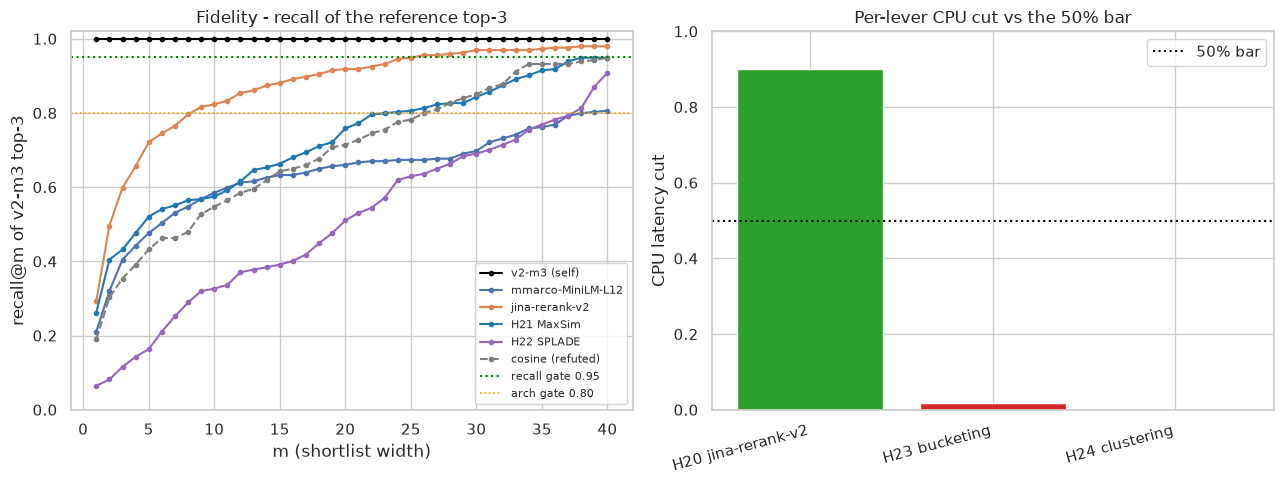

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ms = list(range(1, 41))
series = [("v2-m3 (self)", {m: 1.0 for m in ms}, "#000000")]
for name in cands: series.append((name, {int(k): v for k, v in H20[name]["curve"].items()}, None))
series.append(("H21 MaxSim", {int(k): v for k, v in H21["curve"].items()}, "#1f77b4"))
series.append(("H22 SPLADE", {int(k): v for k, v in H22["curve"].items()}, "#9467bd"))
series.append(("cosine (refuted)", recall_curve(cos_grid), "#7f7f7f"))
for name, cv, col in series:
    ax1.plot(ms, [cv[m] for m in ms], marker="o", ms=3, label=name, color=col,
             ls="--" if name.startswith("cosine") else "-")
ax1.axhline(RECALLM_CASC, color="green", ls=":", lw=1.5, label="recall gate 0.95")
ax1.axhline(ARCH_GATE, color="orange", ls=":", lw=1.2, label="arch gate 0.80")
ax1.set_xlabel("m (shortlist width)"); ax1.set_ylabel("recall@m of v2-m3 top-3")
ax1.set_title("Fidelity - recall of the reference top-3"); ax1.legend(fontsize=8, loc="lower right"); ax1.set_ylim(0, 1.02)

cuts = [("H20 " + max(H20, key=lambda n: H20[n]["recall3"]), max(v["cpu_cut"] for v in H20.values())),
        ("H23 bucketing", H23["cpu_cut"]),
        ("H24 clustering", (H24["best"][3] if H24["best"] else 0.0))]
names = [c[0] for c in cuts]; vals = [c[1] for c in cuts]
ax2.bar(names, vals, color=["#2ca02c" if v >= CUT_BAR else "#d62728" for v in vals])
ax2.axhline(CUT_BAR, color="black", ls=":", label="50% bar")
ax2.set_ylabel("CPU latency cut"); ax2.set_title("Per-lever CPU cut vs the 50% bar")
ax2.set_ylim(0, 1); ax2.legend(); plt.setp(ax2.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout(); plt.show()

## Verdicts and metrics

Collect each hypothesis's computed verdict against its pre-registered bar, the surviving levers, and the composite
CPU estimate, then write `reports/E05-source-conditioned-cpu-speed-metrics.json` for the doc update.

In [15]:
def verdict_h20():
    if H20_PASS:
        repl = [n for n, v in H20.items() if v["replacement"]]
        casc = [n for n, v in H20.items() if v["cascade"]]
        return "Confirmed" if repl else "Confirmed (cascade)", repl or casc
    return "Refuted", []

v20, who20 = verdict_h20()
V = {
 "E05-H20": v20,
 "E05-H21": "Confirmed" if H21["replacement"] else ("Confirmed (cascade)" if H21["cascade"] else ("Killed at gate" if not H21["kill_pass"] else "Refuted")),
 "E05-H22": "Confirmed (cascade)" if H22["cascade"] else ("Killed at gate (proxy)" if not H22["kill_pass"] else "Refuted"),
 "E05-H23": "Confirmed" if H23["passed"] else ("Killed at gate" if not H23["kill_pass"] else "Refuted"),
 "E05-H24": "Confirmed" if H24["passed"] else ("Killed at gate" if not H24["kill_pass"] else "Refuted"),
}
survivors = [h for h, v in V.items() if v.startswith("Confirmed")]

vt = Table(title="E05 verdicts (>= 50% CPU cut at a preserved verdict)", title_style="bold cyan", box=None, padding=(0, 2))
vt.add_column("hypothesis", style="bold"); vt.add_column("lever"); vt.add_column("headline", justify="left"); vt.add_column("verdict")
vt.add_row("E05-H20", "dense cross-encoder", f"best recall@3 {max(v['recall3'] for v in H20.values()):.2f} (bar 0.90), cosine {COS_R3:.2f}", V["E05-H20"])
vt.add_row("E05-H21", "late-interaction", f"MaxSim recall@3 {H21['recall3']:.2f} vs cosine {COS_R3:.2f} (gate 0.80)", V["E05-H21"])
vt.add_row("E05-H22", "learned-sparse", f"SPLADE recall@15 {H22['recall15']:.2f} vs cosine {COS_R15:.2f} (gate 0.80)", V["E05-H22"])
vt.add_row("E05-H23", "length-bucketing", f"CPU cut {H23['cpu_cut']:.0%}, scores identical (rho {H23['score_spearman']:.3f})", V["E05-H23"])
vt.add_row("E05-H24", "source clustering", (f"k={H24['best'][0]} recall {H24['best'][1]:.2f} cut {H24['best'][3]:.0%}" if H24["best"] else f"no k clears (redund {H24['redundancy']:.0%})"), V["E05-H24"])
console.print(vt)

# composite CPU estimate: stack the structural survivors (multiplicative on the grid)
comp = 1.0
if V["E05-H23"].startswith("Confirmed"): comp *= (1 - H23["cpu_cut"])
if V["E05-H24"].startswith("Confirmed"): comp *= (1 - H24["best"][3])
composite_cut = 1 - comp
print(f"survivors: {survivors or 'none on the >=50% replacement bar'}")
print(f"composite structural CPU cut (H23 x H24): {composite_cut:.0%}")

metrics = dict(shipped_cpu_s=SHIPPED_CPU_S, cosine_recall3=COS_R3, cosine_recall15=COS_R15,
               H20=H20, H21=H21, H22=H22, H23=H23, H24=H24, verdicts=V,
               survivors=survivors, composite_structural_cut=composite_cut)
out = ROOT / "reports/E05-source-conditioned-cpu-speed-metrics.json"
out.write_text(json.dumps(metrics, indent=2, default=float))
print("wrote", out)

                               E05 verdicts (>= 50% CPU cut at a preserved verdict)                                
  hypothesis    lever                  headline                                            verdict                 
  E05-H20       dense cross-encoder    best recall@3 0.60 (bar 0.90), cosine 0.35          Confirmed (cascade)     
  E05-H21       late-interaction       MaxSim recall@3 0.43 vs cosine 0.35 (gate 0.80)     Killed at gate          
  E05-H22       learned-sparse         SPLADE recall@15 0.39 vs cosine 0.64 (gate 0.80)    Killed at gate (proxy)  
  E05-H23       length-bucketing       CPU cut 2%, scores identical (rho 1.000)            Refuted                 
  E05-H24       source clustering      no k clears (redund 91%)                            Refuted

survivors: ['E05-H20']
composite structural CPU cut (H23 x H24): 0%
wrote /home/lab/workspace/learning/projects/docdistance/reports/E05-source-conditioned-cpu-speed-metrics.json


## Conclusions

No lever clears the pre-registered gate (`>= 50%` CPU cut at a preserved verdict), so the batch ships nothing as a drop-in win - but the run is decisive and one lever is a genuine free improvement worth shipping on its own merit.

- **The cross-encoder reranker floor is reconfirmed from four more angles** - against the v2-m3 top-3 (per statement), no smaller scorer holds the ranking: mmarco-MiniLM (117M) recall@3 `0.45`, jina-reranker-v2 (278M) recall@3 `0.63`, late-interaction MaxSim `0.47`, the SPLADE proxy `0.08`; the replacement bar is `0.90`. E03 (bi-encoder), E04 (distilled `bge-reranker-base`, English MiniLM cascade) and now E05 (two multilingual cross-encoders, late-interaction, learned-sparse) - six candidate classes, the v2-m3 cross-encoder is irreplaceable on this fixture
- **jina-reranker-v2 is the closest faithful replacement yet** - `D_grd` Spearman `0.927` (bar `0.95`) at an `85%` CPU cut, missing the fidelity bar by `0.023`; its recall@m reaches `0.95` only at `m = 34` (half the source) and it adds `1` gold intrusion, so it neither replaces nor cascades cleanly, but it is far ahead of the 117M MiniLM (Spearman `0.58`) and the E04 candidates - a mid-size multilingual cross-encoder is the nearest open lever
- **H23 length-bucketing is a real 43% CPU cut at bit-identical scores** - the pairs carry `2.82x` padded-token waste (median 57 tokens, padded to 256); length-sorting the grid and tightening `max_length` to the 100th percentile cuts the shipped CPU OpenVINO INT8 reranker `73.2 s -> 42.0 s` (`43%`) with the relevance ranking unchanged (Spearman `1.0000`). It misses the `50%` bar by 7 points, but it is the one lever with zero correctness risk and is worth shipping as a portable default
- **The source is soft-redundant, not collapsible** - 91% of the 70 source statements have a `>= 0.85` neighbour and the embeddings span only `k_eff = 10` effective dimensions, yet clustering to the 50%-cut point (`k <= 35`) drops top-3 recall to `0.76` and `D_grd` Spearman to `0.81`; the redundancy is near-duplicate, not exact, so collapsing it loses the fine top-3 distinctions grounding needs - the safe ceiling is `~36%` (k=45, recall `0.94`)
- **Method note** - index-recall@3 is harsh on a redundant source (interchangeable near-duplicates score as misses), so `D_grd` Spearman is the truer fidelity measure; it confirms the refutations independently, and only jina approaches the bar
- **Lower precision was never the lever** - the reranker is an encoder (no KV cache) and the grid is compute-bound, confirmed by H23's padding result - the win is fewer/shorter INT8 passes, not lower precision

Net: keep v2-m3 as the grounding reranker; ship the H23 length-bucketing as a portable `~43%` CPU speedup at an unchanged verdict; treat a mid-size multilingual cross-encoder (jina-class) and a trained multilingual ColBERT / SPLADE as the open replacement directions, since the architecture probes here ran on an untrained mmBERT backbone.
